<div align="center"; style="background-color: rgba(173, 216, 230, 0.4); padding: 10px; border-radius: 6px;">
<h1>Block 1: Set Up</h1>
</div>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

In [2]:
prices = pd.read_csv('price.csv')
prices.drop(columns=['Unnamed: 0'], inplace=True)

In [3]:
prices.head()

,id,name,timestamp,open,high,low,close,volume
0,bitcoin,Bitcoin,2025-02-20,96554.871563,96554.871563,96554.871563,96554.871563,2.770322e+10
1,bitcoin,Bitcoin,2025-02-21,98384.317382,98384.317382,98384.317382,98384.317382,2.417526e+10
2,bitcoin,Bitcoin,2025-02-22,96135.155413,96135.155413,96135.155413,96135.155413,4.247747e+10
3,bitcoin,Bitcoin,2025-02-23,96564.154143,96564.154143,96564.154143,96564.154143,1.846442e+10
4,bitcoin,Bitcoin,2025-02-24,96327.463091,96327.463091,96327.463091,96327.463091,1.664304e+10


In [4]:
prices.describe()

,open,high,low,close,volume
count,18250.000000,18250.000000,18250.000000,18250.000000,1.825000e+04
mean,4328.259766,4328.291621,4328.257317,4328.289172,3.653505e+09
std,19636.879373,19636.978574,19636.879707,19636.978908,1.488388e+10
min,0.000623,0.000623,0.000623,0.000623,3.900928e+04
25%,0.316048,0.316048,0.316048,0.316048,3.315121e+07
50%,1.031556,1.031556,1.031556,1.031556,1.225833e+08
75%,41.864508,41.864508,41.864508,41.864508,4.697495e+08
max,124798.907724,124798.907724,124798.907724,124798.907724,2.794751e+11


In [5]:
ratings = pd.read_excel('Data.xlsx', sheet_name = 'Summary')

In [6]:
ratings.head()

,CoinGecko_ID,Name,Symbol,E,S,G,TOTAL
0,bitcoin,Bitcoin,BTC,0,2,1,3
1,ethereum,Ethereum,ETH,1,4,1,6
2,binancecoin,BNB,BNB,2,4,0,6
3,solana,Solana,SOL,2,4,1,7
4,cardano,Cardano,ADA,3,6,2,11


<div align="center"; style="background-color: rgba(173, 216, 230, 0.4); padding: 10px; border-radius: 6px;">
<h1>Block 2: Grouping</h1>
</div>

#### ESG Rating Criteria (reference: [Cryptos ESG ratings and price crash risks](https://www.tandfonline.com/doi/full/10.1080/23311975.2025.2557976))


| ESG Factor      | Rating | Criteria                                                                                                                             | Justification                                                                                                                                                                                                                                        |
| --------------- | ------ | ------------------------------------------------------------------------------------------------------------------------------------ | ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Environment** | 0      | PoW                                                                                                                                  | PoW mechanisms are energy-intensive, creating a large carbon footprint and environmental harm (De Vries, 2018; Sedlmeier et al., 2020).                                                                                                              |
|                 | 1      | PoS                                                                                                                                  | Compared to PoW, PoS removes complicated computational mining and significantly reduces energy consumption (Asif & Hassan, 2023; Saleh, 2021).                                                                                                       |
|                 | 2      | Delegated PoS and other energy-efficient consensus mechanisms                                                                        | Improvements upon PoS with higher efficiency or hybrid models that further reduce environmental costs while maintaining security and decentralisation (Saad et al., 2021).                                                                           |
|                 | 3      | Address environmental challenges (e.g., reducing energy use in supply chains, file storage, energy trading, industrial applications) | Go beyond efficiency and actively promote sustainability, such as reducing energy consumption in industrial processes or enabling carbon trading, clean energy markets, or sustainable supply chains (Andoni et al., 2019; Parmentola et al., 2022). |
| **Social**      | 0      | Enterprise cryptos and meme coins                                                                                                    | Often lack social utility, functioning primarily as speculative instruments or internal tokens (Krause, 2025).                                                                                                                                       |
|                 | 1      | Entertainment, gaming, and media cryptos                                                                                             | Promote user engagement but have moderate social impact in terms of financial or digital inclusion (Paduraru et al., 2022).                                                                                                                          |
|                 | 2      | Payments and tokenisation crypto                                                                                                     | Used for payments or remittances, reducing transaction costs and increasing access to financial services (Sukarno, 2020).                                                                                                                            |
|                 | 3      | Stablecoins                                                                                                                          | Maintain price stability and support monetary stability, especially in volatile economies (Bullmann et al., 2019).                                                                                                                                   |
|                 | 4      | DApps, DeFi, and Web3 cryptos                                                                                                        | Enhance accessibility, autonomy, and decentralisation of online services, key values in digital society (Zetzsche et al., 2020).                                                                                                                     |
|                 | 5      | Privacy coins                                                                                                                        | Promote anonymity, supporting data ownership and digital rights (Ibikunle et al., 2025).                                                                                                                                                             |
|                 | 6      | Social mission-focused cryptos                                                                                                       | Designed to address specific social challenges (e.g., cloud storage, energy democratisation, transportation facilitation, supply chain transparency), reflecting high societal value (Gochhayat et al., 2019).                                       |
| **Governance**  | 0      | Centralised governance                                                                                                               | Centralised control increases the risk of manipulation and censorship, undermining decentralisation (Catalini & Gans, 2020).                                                                                                                         |
|                 | 1      | Community governance with founder influence                                                                                          | Appears decentralised but decision-making remains skewed toward early stakeholders or developers.                                                                                                                                                    |
|                 | 2      | Token voting systems                                                                                                                 | Allow token holders to participate in governance, enhancing fairness and transparency.                                                                                                                                                               |
|                 | 3      | Council/community governance                                                                                                         | Most robust form of decentralised governance involving open discourse or oversight by global organisations, ensuring inclusive, transparent, and resilient decision-making.                                                                          |


In [7]:
ratings['ESG_group'] = pd.cut(
    ratings['TOTAL'],
    bins=[0, 4, 7, 12], 
    labels=['Low', 'Mid', 'High']
)

print(ratings['ESG_group'].value_counts())

ESG_group
High    19
Mid     18
Low     13
Name: count, dtype: int64


In [8]:
ratings.head()

,CoinGecko_ID,Name,Symbol,E,S,G,TOTAL,ESG_group
0,bitcoin,Bitcoin,BTC,0,2,1,3,Low
1,ethereum,Ethereum,ETH,1,4,1,6,Mid
2,binancecoin,BNB,BNB,2,4,0,6,Mid
3,solana,Solana,SOL,2,4,1,7,Mid
4,cardano,Cardano,ADA,3,6,2,11,High


In [9]:
prices = prices.merge(ratings, left_on='id', right_on='CoinGecko_ID', how='left')

<div align="center"; style="background-color: rgba(173, 216, 230, 0.4); padding: 10px; border-radius: 6px;">
<h1>Block 3: Feature Engineering</h1>
</div>

## 3.1 Daily Returns

In [10]:
prices['returns'] = prices.groupby('id')['close'].pct_change()

## 3.2 Calendar Features

In [11]:
prices['timestamp'] = pd.to_datetime(prices['timestamp'])

In [12]:
prices['month']      = prices['timestamp'].dt.month
prices['day_of_week'] = prices['timestamp'].dt.dayofweek
prices['is_weekend']  = prices['day_of_week'].isin([5, 6]).astype(int)

In [13]:
# first and last 3 trading days
prices['day_of_month']  = prices['timestamp'].dt.day
prices['days_in_month']  = prices['timestamp'].dt.days_in_month
prices['is_turn_of_month'] = (
    (prices['day_of_month'] <= 3) | 
    (prices['day_of_month'] >= prices['days_in_month'] - 2)
).astype(int)

In [14]:
prices.head()

,id,name,timestamp,open,high,low,close,volume,CoinGecko_ID,Name,...,G,TOTAL,ESG_group,returns,month,day_of_week,is_weekend,day_of_month,days_in_month,is_turn_of_month
0,bitcoin,Bitcoin,2025-02-20,96554.871563,96554.871563,96554.871563,96554.871563,2.770322e+10,bitcoin,Bitcoin,...,1,3,Low,NaN,2,3,0,20,28,0
1,bitcoin,Bitcoin,2025-02-21,98384.317382,98384.317382,98384.317382,98384.317382,2.417526e+10,bitcoin,Bitcoin,...,1,3,Low,0.018947,2,4,0,21,28,0
2,bitcoin,Bitcoin,2025-02-22,96135.155413,96135.155413,96135.155413,96135.155413,4.247747e+10,bitcoin,Bitcoin,...,1,3,Low,-0.022861,2,5,1,22,28,0
3,bitcoin,Bitcoin,2025-02-23,96564.154143,96564.154143,96564.154143,96564.154143,1.846442e+10,bitcoin,Bitcoin,...,1,3,Low,0.004462,2,6,1,23,28,0
4,bitcoin,Bitcoin,2025-02-24,96327.463091,96327.463091,96327.463091,96327.463091,1.664304e+10,bitcoin,Bitcoin,...,1,3,Low,-0.002451,2,0,0,24,28,0


## 3.3 60-day rolling volatility

In [15]:
prices['rolling_vol'] = (
    prices.groupby('id')['returns']
    .transform(lambda x: x.rolling(60).std())
)

## 3.4 Risk Adjusted Return

In [16]:
prices['risk_adj_daily'] = prices['returns'] / prices['rolling_vol']

<div align="center"; style="background-color: rgba(173, 216, 230, 0.4); padding: 10px; border-radius: 6px;">
<h1>Block 4: Rate of Returns</h1>
</div>

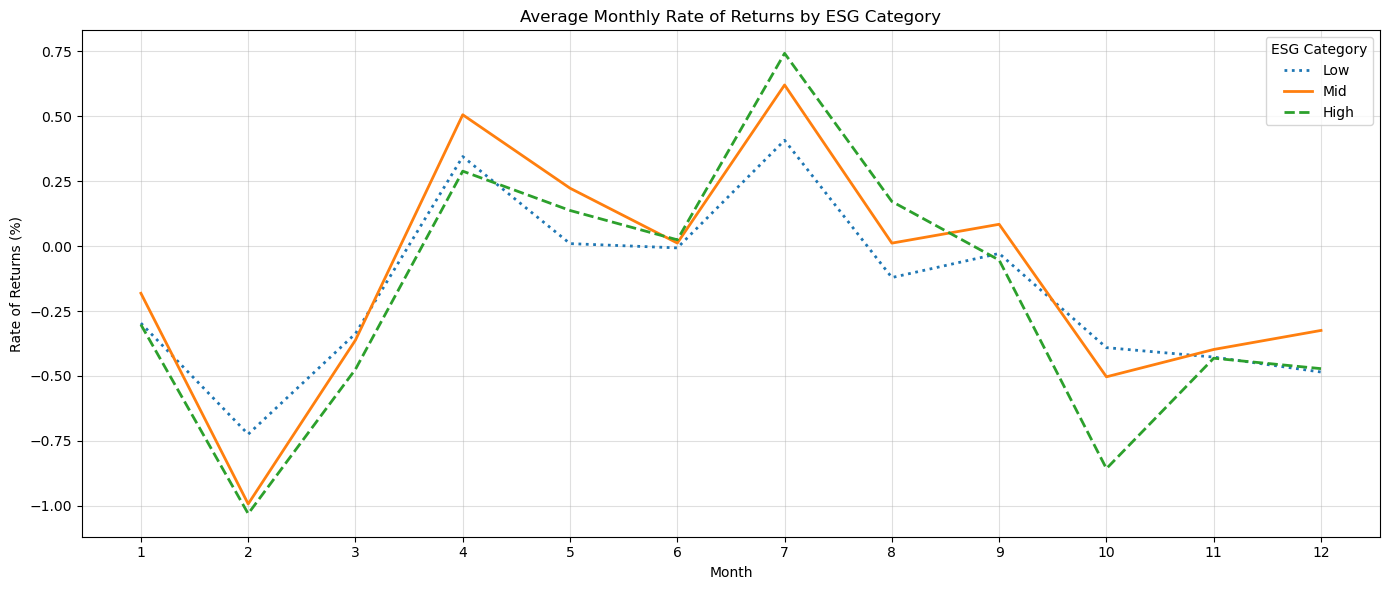

In [17]:
returns = (
    prices.pivot_table(
        index=['ESG_group', 'month'],
        values='returns',
        aggfunc='mean',
        observed=False
    ).reset_index()
)

styles = {
    'Low':  {'linestyle': ':',  'linewidth': 2},
    'Mid':  {'linestyle': '-',  'linewidth': 2},
    'High': {'linestyle': '--', 'linewidth': 2},
}

fig, ax = plt.subplots(figsize=(14, 6))
for group_name, subset in returns.groupby('ESG_group', observed=True):
    ax.plot(
        subset['month'],
        subset['returns'] * 100,     
        label=group_name,
        **styles[group_name]
    )
ax.set_title('Average Monthly Rate of Returns by ESG Category')
ax.set_ylabel('Rate of Returns (%)')
ax.set_xlabel('Month')
ax.set_xticks(range(1, 13))
ax.legend(title='ESG Category')
ax.grid(axis='both', alpha=0.4)
plt.tight_layout()
plt.show()

<div style="background-color:#ffe6f0; padding:15px; border-radius:8px;">

<h3>There appears to be no clear hierarchical relationship among low, mid, and high ESG score cryptocurrencies.</h3>

</div>

<div align="center"; style="background-color: rgba(173, 216, 230, 0.4); padding: 10px; border-radius: 6px;">
<h1>Block 5: Volatility</h1>
</div>

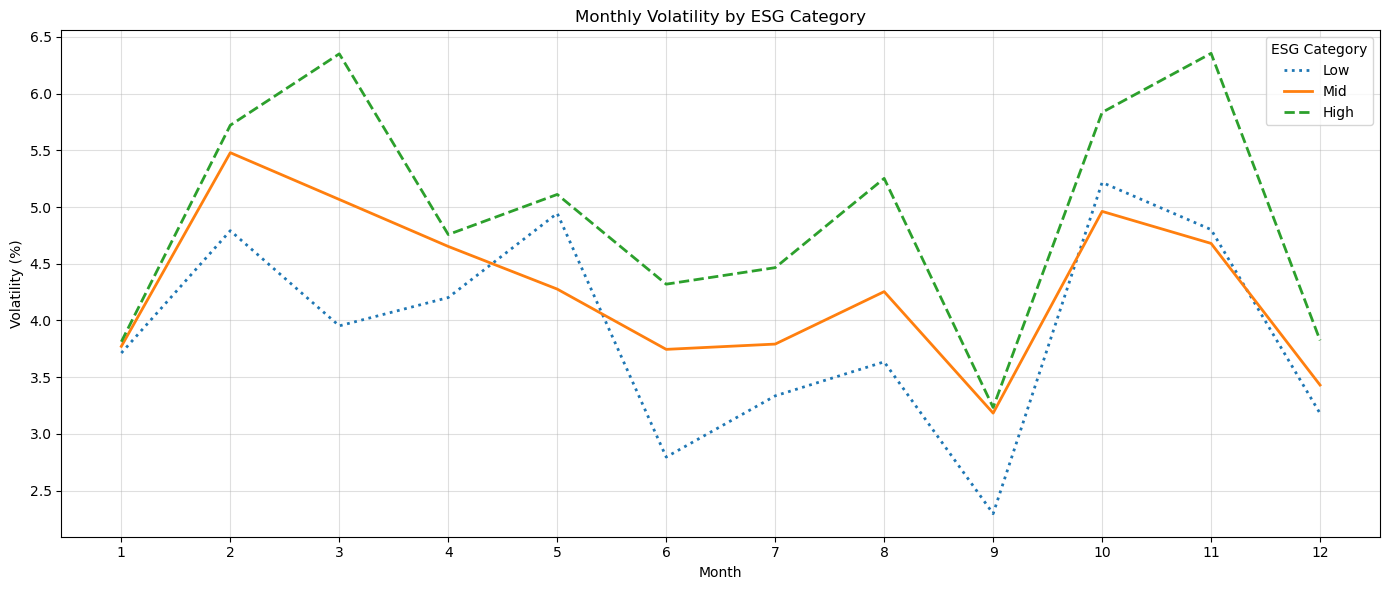

In [18]:
volatility = (
    prices.pivot_table(
        index=['ESG_group', 'month'],
        values='returns',
        aggfunc='std',
        observed=False
    ).reset_index()
)

fig, ax = plt.subplots(figsize=(14, 6))
for group_name, subset in volatility.groupby('ESG_group', observed=True):
    ax.plot(
        subset['month'],
        subset['returns'] * 100,       # Convert to percentage
        label=group_name,
        **styles[group_name]
    )
ax.set_title('Monthly Volatility by ESG Category')
ax.set_ylabel('Volatility (%)')
ax.set_xlabel('Month')
ax.set_xticks(range(1, 13))
ax.legend(title='ESG Category')
ax.grid(axis='both', alpha=0.4)
plt.tight_layout()
plt.show()


<div style="background-color:#ffe6f0; padding:15px; border-radius:8px;">

<h3>High ESG score cryptocurrencies seem to be exhibiting higher volatility compared to others.</h3>

</div>

<div align="center"; style="background-color: rgba(173, 216, 230, 0.4); padding: 10px; border-radius: 6px;">
<h1>Block 6: Sharpe Ratio</h1>
</div>

In [19]:
# Here we approximate with ~4.5% annual = 0.045/365 daily
RISK_FREE_DAILY = 0.045 / 365

crypto_sharpe = (
    prices.groupby(['id', 'ESG_group'], observed=True)['returns']
    .agg(['mean', 'std'])
    .reset_index()
)

# Subtract risk-free rate before computing Sharpe
crypto_sharpe['sharpe_daily']  = (crypto_sharpe['mean'] - RISK_FREE_DAILY) / crypto_sharpe['std']
crypto_sharpe['sharpe_annual'] = crypto_sharpe['sharpe_daily'] * np.sqrt(365)

print("Mean Annualised Sharpe Ratio by ESG Group:")
print(crypto_sharpe.groupby('ESG_group', observed=True)['sharpe_annual'].mean())


Mean Annualised Sharpe Ratio by ESG Group:
ESG_group
Low    -2.863590
Mid    -0.721062
High   -0.728400
Name: sharpe_annual, dtype: float64


<div style="padding:15px; border-radius:8px;">

<h3>One-Way ANOVA Test on Sharpe Ratios</h3>

<h4>1) We perform a one-way ANOVA to test whether the mean annualised Sharpe ratios differ across Low, Mid, and High ESG groups.</h4>
<h4>2) The test compares between-group variance to within-group variance to determine if observed differences are statistically meaningful.s.</h3>

</div>

In [20]:
from scipy.stats import f_oneway

low  = crypto_sharpe[crypto_sharpe['ESG_group']=='Low']['sharpe_annual']
mid  = crypto_sharpe[crypto_sharpe['ESG_group']=='Mid']['sharpe_annual']
high = crypto_sharpe[crypto_sharpe['ESG_group']=='High']['sharpe_annual']

f_stat, p_value = f_oneway(low, mid, high)

print("F-stat:", f_stat)
print("p-value:", p_value)

F-stat: 4.72731856113291
p-value: 0.013469720582860922


<div style="background-color:#ffe6f0; padding:15px; border-radius:8px;">

<h3>Low ESG coins had:</h3>

<h4>1) Much worse risk-adjusted performance</h4>
<h4>2) Very poor excess return per unit risk</h4>

<h3>Since p-value is smaller than 0.05, we are 95% confident thSharpe ratio differs across the 3 categoriesificant.</h3>

</div>

<div align="center"; style="background-color: rgba(173, 216, 230, 0.4); padding: 10px; border-radius: 6px;">
<h1>Block 7: Max Drawdown</h1>
</div>

Mean Max Drawdown by ESG Group:
ESG_group
Low    -0.500768
Mid    -0.615582
High   -0.750281
Name: max_drawdown, dtype: float64


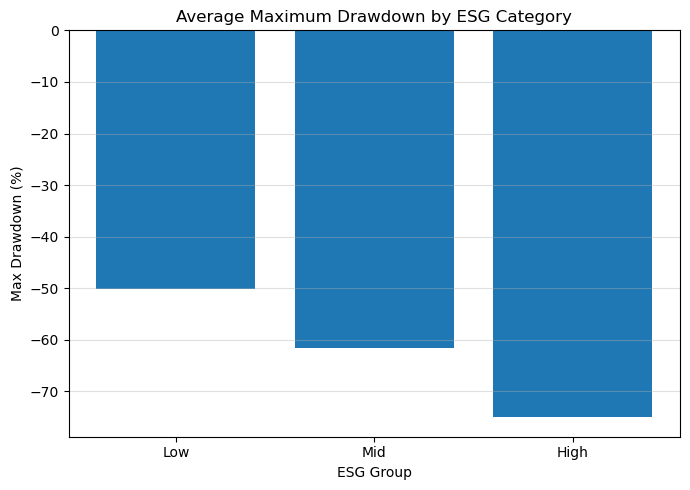

In [21]:
def max_drawdown(series):
    """Computes maximum drawdown from a price or cumulative return series."""
    cumulative = (1 + series.fillna(0)).cumprod()
    rolling_max = cumulative.cummax()
    drawdown = (cumulative - rolling_max) / rolling_max
    return drawdown.min()

mdd = (
    prices.groupby(['id', 'ESG_group'], observed=True)['returns']
    .apply(max_drawdown)
    .reset_index()
    .rename(columns={'returns': 'max_drawdown'})
)

print("Mean Max Drawdown by ESG Group:")
print(mdd.groupby('ESG_group', observed=True)['max_drawdown'].mean())

# ── Bar chart of average max drawdown per ESG group
mdd_summary = mdd.groupby('ESG_group', observed=True)['max_drawdown'].mean().reset_index()
fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(mdd_summary['ESG_group'], mdd_summary['max_drawdown'] * 100)
ax.set_title('Average Maximum Drawdown by ESG Category')
ax.set_ylabel('Max Drawdown (%)')
ax.set_xlabel('ESG Group')
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()


In [22]:
from scipy.stats import f_oneway

low  = mdd[mdd['ESG_group']=='Low']['max_drawdown']
mid  = mdd[mdd['ESG_group']=='Mid']['max_drawdown']
high = mdd[mdd['ESG_group']=='High']['max_drawdown']

f_stat, p_value = f_oneway(low, mid, high)

print("F-statistic:", f_stat)
print("p-value:", p_value)

F-statistic: 3.9477585563687048
p-value: 0.026012552547058664


<div style="background-color:#ffe6f0; padding:15px; border-radius:8px;">

<h3>High ESG coins had:</h3>

<h4>1) The largest average maximum drawdowns (~75%)</h4>
<h4>2) Greater downside risk compared to Mid (~62%) and Low (~50%) ESG coins</h4>

<h3>Since p-value is smaller than 0.05, we are 95% confident that the differences in maximum drawdown across ESG groups are statistically significant.</h3>

</div>

</div>

<div align="center"; style="background-color: rgba(173, 216, 230, 0.4); padding: 10px; border-radius: 6px;">
<h1>Block 8: Crisis Period Return</h1>
</div>

In [23]:
# ── Define crisis windows (adjust dates to match your data range)
crisis_periods = {
    'Crypto Crash 2025': ('2025-10-01', '2025-11-01'),
}

print("Average Returns During Crisis Periods by ESG Group:\n")
for label, (start, end) in crisis_periods.items():
    crisis_data = prices[
        (prices['timestamp'] >= start) & (prices['timestamp'] <= end)
    ]
    if crisis_data.empty:
        print(f"{label}: No data in range.\n")
        continue
    summary = (
        crisis_data.groupby('ESG_group', observed=True)['returns']
        .mean()
        .mul(100)
        .round(4)
    )
    print(f"{label}:")
    print(summary.to_string())
    print()


Average Returns During Crisis Periods by ESG Group:

Crypto Crash 2025:
ESG_group
Low    -0.3410
Mid    -0.4575
High   -0.7919



<div style="background-color:#ffe6f0; padding:15px; border-radius:8px;">

<h3>During the Crypto Crash 2025 crisis window:</h3>

<h4>1) High ESG coins experienced the largest average losses (~-79%)</h4>
<h4>2) Mid ESG coins declined by ~-46%, while Low ESG coins fell by ~-34%</h4>

<h3>This indicates that High ESG cryptocurrencies were the most vulnerable during crisis conditions, exhibiting substantially greater downside exposure compared to other ESG categories.</h3>

</div>

<div align="center"; style="background-color: rgba(173, 216, 230, 0.4); padding: 10px; border-radius: 6px;">
<h1>Block 9: Behavioural Finance</h1>
</div>

## 9.1 Turn-of-the-Month Effect

In [24]:
tom = prices.groupby(['ESG_group', 'is_turn_of_month'], observed=True)['returns'].mean().unstack()
tom.columns = ['Non-Turn', 'Turn-of-Month']
tom['Difference'] = tom['Turn-of-Month'] - tom['Non-Turn']
print("Turn-of-the-Month Effect (Mean Daily Return):\n")
print((tom * 100).round(4))

# ── Statistical test per group
print("\nT-tests (Turn vs. Non-Turn):")
for group in prices['ESG_group'].dropna().unique():
    sub = prices[prices['ESG_group'] == group]
    turn    = sub[sub['is_turn_of_month'] == 1]['returns'].dropna()
    non_turn = sub[sub['is_turn_of_month'] == 0]['returns'].dropna()
    t, p = stats.ttest_ind(turn, non_turn)
    print(f"  {group}: t={t:.4f}, p={p:.4f}")


Turn-of-the-Month Effect (Mean Daily Return):

           Non-Turn  Turn-of-Month  Difference
ESG_group                                     
Low         -0.1636        -0.1802     -0.0165
Mid         -0.0487        -0.3132     -0.2645
High        -0.1009        -0.5036     -0.4027

T-tests (Turn vs. Non-Turn):
  Low: t=-0.1132, p=0.9099
  Mid: t=-1.9690, p=0.0490
  High: t=-2.6531, p=0.0080


<div style="background-color:#ffe6f0; padding:15px; border-radius:8px;">

<h3>Turn-of-the-Month Effect</h3>

<h4>1) No significant turn-of-month effect is observed for Low ESG cryptocurrencies (p = 0.91).</h4>
<h4>2) Mid ESG cryptocurrencies exhibit significantly lower returns during turn-of-month periods (p = 0.049).</h4>
<h4>3) High ESG cryptocurrencies show a strongly significant negative turn-of-month effect (p = 0.008).</h4>

<h3>Contrary to traditional equity markets, the turn-of-month effect in crypto appears negative, particularly for higher ESG categories.</h3>

</div>

## 9.2 Day-of-the-Week Effect

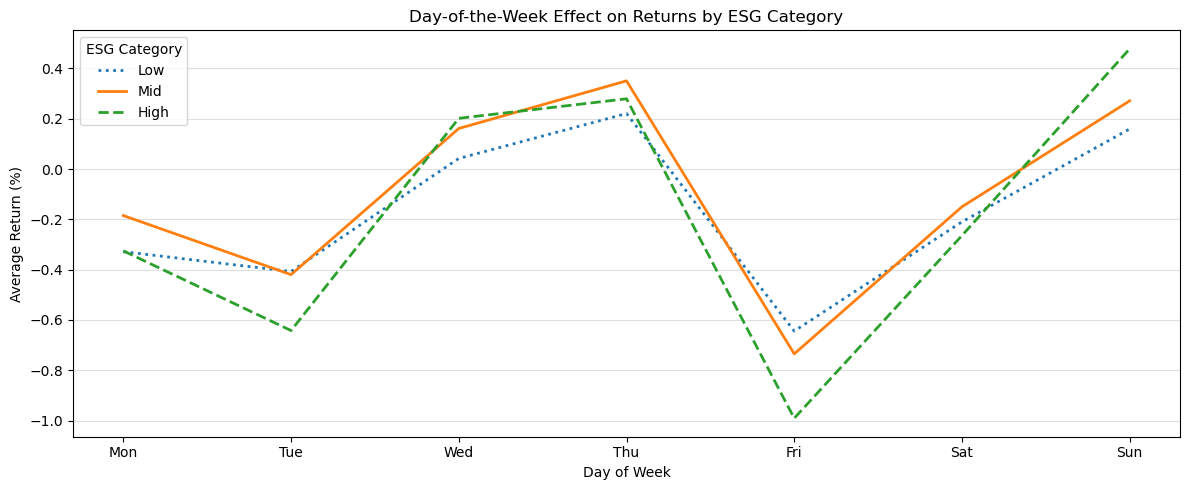

ANOVA — Day-of-Week Effect:
  Low: F=4.3269, p=0.0002
  Mid: F=7.7196, p=0.0000
  High: F=11.0791, p=0.0000


In [25]:
day_labels = {0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu', 4: 'Fri', 5: 'Sat', 6: 'Sun'}

dow = (
    prices.groupby(['ESG_group', 'day_of_week'], observed=True)['returns']
    .mean()
    .reset_index()
)
dow['day_name'] = dow['day_of_week'].map(day_labels)

fig, ax = plt.subplots(figsize=(12, 5))
for group_name, subset in dow.groupby('ESG_group', observed=True):
    ax.plot(subset['day_name'], subset['returns'] * 100, label=group_name, **styles[group_name])
ax.set_title('Day-of-the-Week Effect on Returns by ESG Category')
ax.set_ylabel('Average Return (%)')
ax.set_xlabel('Day of Week')
ax.legend(title='ESG Category')
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

# ── One-way ANOVA across days of the week per ESG group
print("ANOVA — Day-of-Week Effect:")
for group in prices['ESG_group'].dropna().unique():
    sub = prices[prices['ESG_group'] == group]
    day_groups = [sub[sub['day_of_week'] == d]['returns'].dropna() for d in range(7)]
    day_groups = [g for g in day_groups if len(g) > 1]
    f, p = stats.f_oneway(*day_groups)
    print(f"  {group}: F={f:.4f}, p={p:.4f}")


<div style="background-color:#ffe6f0; padding:15px; border-radius:8px;">

<h3>Day-of-the-Week Effect</h3>

<h4>1) One-way ANOVA tests indicate statistically significant differences in weekday returns for all ESG categories (p < 0.001).</h4>
<h4>2) Returns vary systematically across days, with Tuesday and Friday exhibiting weaker performance and mid-week days showing stronger returns.</h4>
<h4>3) The calendar effect is strongest for High ESG cryptocurrencies, as reflected by the largest F-statistic (F = 11.08).</h4>

<h3>This suggests that cryptocurrency returns are not time-invariant and that higher ESG coins exhibit greater sensitivity to weekday trading patterns.</h3>

</div>

## 9.3 Weekend Effect


In [26]:
# ── Crypto trades 24/7, so weekend vs. weekday is meaningful unlike equities
weekend = prices.groupby(['ESG_group', 'is_weekend'], observed=True)['returns'].mean().unstack()
weekend.columns = ['Weekday', 'Weekend']
weekend['Difference'] = weekend['Weekend'] - weekend['Weekday']
print("Weekend Effect (Mean Daily Return):\n")
print((weekend * 100).round(4))

# ── T-test for each ESG group
print("\nT-tests (Weekend vs. Weekday):")
for group in prices['ESG_group'].dropna().unique():
    sub = prices[prices['ESG_group'] == group]
    wknd  = sub[sub['is_weekend'] == 1]['returns'].dropna()
    wkday = sub[sub['is_weekend'] == 0]['returns'].dropna()
    t, p = stats.ttest_ind(wknd, wkday)
    print(f"  {group}: t={t:.4f}, p={p:.4f}")


Weekend Effect (Mean Daily Return):

           Weekday  Weekend  Difference
ESG_group                              
Low        -0.2235  -0.0254      0.1981
Mid        -0.1656   0.0604      0.2260
High       -0.2954   0.1067      0.4021

T-tests (Weekend vs. Weekday):
  Low: t=1.5377, p=0.1242
  Mid: t=1.9077, p=0.0565
  High: t=3.0050, p=0.0027


<div style="background-color:#ffe6f0; padding:15px; border-radius:8px;">

<h3>Weekend Effect</h3>

<h4>1) Weekend returns are higher than weekday returns across all ESG categories.</h4>
<h4>2) The effect is strongest for High ESG cryptocurrencies (Weekend − Weekday ≈ +0.40%).</h4>
<h4>3) A statistically significant weekend premium is observed for High ESG coins (t = 3.01, p = 0.0027).</h4>

<h3>This suggests that higher ESG cryptocurrencies exhibit stronger behavioural or liquidity-driven trading patterns during weekends.</h3>

</div>

## 9.4 Holiday Effect

In [27]:
# ── Define major holidays (US-based)
# Install with: pip install holidays
import holidays as hd

us_holidays = hd.US(years=prices['timestamp'].dt.year.unique().tolist())
holiday_dates = set(us_holidays.keys())

prices['is_holiday'] = prices['timestamp'].dt.date.isin(holiday_dates).astype(int)

holiday_effect = prices.groupby(['ESG_group', 'is_holiday'], observed=True)['returns'].mean().unstack()
holiday_effect.columns = ['Non-Holiday', 'Holiday']
holiday_effect['Difference'] = holiday_effect['Holiday'] - holiday_effect['Non-Holiday']
print("Holiday Effect (Mean Daily Return):\n")
print((holiday_effect * 100).round(4))

# ── T-test
print("\nT-tests (Holiday vs. Non-Holiday):")
for group in prices['ESG_group'].dropna().unique():
    sub = prices[prices['ESG_group'] == group]
    hol     = sub[sub['is_holiday'] == 1]['returns'].dropna()
    non_hol = sub[sub['is_holiday'] == 0]['returns'].dropna()
    if len(hol) < 2:
        print(f"  {group}: Not enough holiday observations.")
        continue
    t, p = stats.ttest_ind(hol, non_hol)
    print(f"  {group}: t={t:.4f}, p={p:.4f}")


Holiday Effect (Mean Daily Return):

           Non-Holiday  Holiday  Difference
ESG_group                                  
Low            -0.1823   0.3263      0.5085
Mid            -0.1138   0.3085      0.4222
High           -0.1968   0.3413      0.5381

T-tests (Holiday vs. Non-Holiday):
  Low: t=1.4955, p=0.1348
  Mid: t=1.3504, p=0.1769
  High: t=1.5233, p=0.1277


<div style="background-color:#ffe6f0; padding:15px; border-radius:8px;">

<h3>Holiday Effect</h3>

<h4>1) Holiday returns appear higher than non-holiday returns across all ESG groups.</h4>
<h4>2) The economic magnitude of the holiday premium ranges from approximately +0.42% to +0.54%.</h4>
<h4>3) However, t-tests indicate that these differences are not statistically significant (p > 0.05).</h4>

<h3>While a positive holiday premium is observed in the data, we cannot conclude that the effect is statistically robust due to limited observations and high return volatility.</h3>

</div>

<div align="center"; style="background-color: rgba(173, 216, 230, 0.4); padding: 10px; border-radius: 6px;">
<h1>Block 10: Linear Regression</h1>
</div>

In [28]:
linear = (
    prices.groupby('id')[['risk_adj_daily', 'E', 'S', 'G']]
    .mean()
    .reset_index()
    .dropna()
)

y = linear['risk_adj_daily']
X = linear[['E', 'S', 'G']]


vif_data = pd.DataFrame({'Feature': X.columns})
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print("VIF Scores (>5 indicates multicollinearity):\n", vif_data)

# ── OLS with robust standard errors (HC3) to handle heteroscedasticity
X_const = sm.add_constant(X)
model = sm.OLS(y, X_const).fit(cov_type='HC3')
print(model.summary())


VIF Scores (>5 indicates multicollinearity):
   Feature        VIF
0       E   9.453833
1       S  10.039208
2       G   3.908783
                            OLS Regression Results                            
Dep. Variable:         risk_adj_daily   R-squared:                       0.450
Model:                            OLS   Adj. R-squared:                  0.415
Method:                 Least Squares   F-statistic:                     8.766
Date:                Fri, 27 Feb 2026   Prob (F-statistic):           0.000105
Time:                        20:54:24   Log-Likelihood:                 110.50
No. Observations:                  50   AIC:                            -213.0
Df Residuals:                      46   BIC:                            -205.3
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-

<div style="background-color:#ffe6f0; padding:15px; border-radius:8px;">

<h3>Cross-Sectional Regression Results</h3>

<h4>1) The ESG pillars jointly explain approximately 45% of the variation in risk-adjusted returns (R² = 0.45, p < 0.001).</h4>
<h4>2) The Social (S) pillar exhibits a positive and statistically significant association with risk-adjusted performance (p = 0.003).</h4>
<h4>3) The Governance (G) pillar shows a significant negative association (p = 0.001), while Environmental (E) effects are negative but marginally insignificant.</h4>

<h3>These findings suggest that ESG components have heterogeneous effects on cryptocurrency performance, with social factors positively related to risk-adjusted returns.</h3>

</div>

<div align="center"; style="background-color: rgba(173, 216, 230, 0.4); padding: 10px; border-radius: 6px;">
<h1>Block 11: Random Forest Regression</h1>
</div>

In [29]:
random = (
    prices.groupby(['id', 'month'])[['risk_adj_daily', 'E', 'S', 'G']]
    .mean()
    .reset_index()
    .dropna()
)

# ── Run two versions: with and without 'month' to isolate ESG signal
for use_month in [True, False]:
    label = "With Month" if use_month else "ESG Only"
    cols  = ['month', 'E', 'S', 'G'] if use_month else ['E', 'S', 'G']

    X = random[cols]
    y = random['risk_adj_daily']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s  = scaler.transform(X_test)

    rf = RandomForestRegressor(n_estimators=200, random_state=42)
    rf.fit(X_train_s, y_train)
    y_pred = rf.predict(X_test_s)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)

    # 5-fold cross-validated R² for more reliable estimate
    cv_r2 = cross_val_score(rf, scaler.fit_transform(X), y, cv=5, scoring='r2').mean()

    print(f"\n── Random Forest ({label}) ──")
    print(f"  Test RMSE : {rmse:.4f}")
    print(f"  Test R²   : {r2:.4f}")
    print(f"  CV R² (5-fold): {cv_r2:.4f}")
    importances = pd.Series(rf.feature_importances_, index=cols).sort_values(ascending=False)
    print(f"  Feature Importances:\n{importances}")




── Random Forest (With Month) ──
  Test RMSE : 0.1246
  Test R²   : 0.4113
  CV R² (5-fold): 0.4611
  Feature Importances:
month    0.647555
G        0.132143
S        0.112551
E        0.107751
dtype: float64

── Random Forest (ESG Only) ──
  Test RMSE : 0.1707
  Test R²   : -0.1056
  CV R² (5-fold): 0.0081
  Feature Importances:
G    0.375007
S    0.368626
E    0.256367
dtype: float64


<div style="background-color:#ffe6f0; padding:15px; border-radius:8px;">

<h3>Random Forest Predictive Analysis</h3>

<h4>1) Including 'month' substantially improves predictive performance (CV R² ≈ 0.46), indicating strong time or regime effects.</h4>
<h4>2) The month variable accounts for approximately 65% of feature importance, dominating ESG pillars.</h4>
<h4>3) ESG variables alone exhibit negligible predictive power (CV R² ≈ 0.01), suggesting limited standalone forecasting ability.</h4>

<h3>These results imply that while ESG factors are associated with cross-sectional performance differences, temporal market structure plays a significantly larger role in explaining variation in risk-adjusted cryptocurrency returns.</h3>

</div>

<div align="center"; style="background-color: rgba(173, 216, 230, 0.4); padding: 10px; border-radius: 6px;">
<h1>Block 12: Gradient Boosting</h1>
</div>

In [30]:
# ── Same two-version structure as Random Forest above
for use_month in [True, False]:
    label = "With Month" if use_month else "ESG Only"
    cols  = ['month', 'E', 'S', 'G'] if use_month else ['E', 'S', 'G']

    X = random[cols]
    y = random['risk_adj_daily']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s  = scaler.transform(X_test)

    gb = GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,    # Lowered for better generalisation
        max_depth=3,
        random_state=42
    )
    gb.fit(X_train_s, y_train)
    y_pred = gb.predict(X_test_s)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    cv_r2 = cross_val_score(gb, scaler.fit_transform(X), y, cv=5, scoring='r2').mean()

    print(f"\n── Gradient Boosting ({label}) ──")
    print(f"  Test RMSE : {rmse:.4f}")
    print(f"  Test R²   : {r2:.4f}")
    print(f"  CV R² (5-fold): {cv_r2:.4f}")
    importances = pd.Series(gb.feature_importances_, index=cols).sort_values(ascending=False)
    print(f"  Feature Importances:\n{importances}")



── Gradient Boosting (With Month) ──
  Test RMSE : 0.1230
  Test R²   : 0.4266
  CV R² (5-fold): 0.4976
  Feature Importances:
month    0.827300
G        0.063359
S        0.056610
E        0.052730
dtype: float64

── Gradient Boosting (ESG Only) ──
  Test RMSE : 0.1701
  Test R²   : -0.0968
  CV R² (5-fold): 0.0129
  Feature Importances:
S    0.454775
G    0.359144
E    0.186080
dtype: float64


<div style="background-color:#ffe6f0; padding:15px; border-radius:8px;">

<h3>Gradient Boosting Predictive Analysis</h3>

<h4>1) Including 'month' yields strong predictive performance (CV R² ≈ 0.50), confirming dominant time/regime effects.</h4>
<h4>2) The month variable accounts for approximately 83% of feature importance, overwhelmingly dominating ESG pillars.</h4>
<h4>3) ESG variables alone exhibit negligible predictive power (CV R² ≈ 0.01), indicating limited standalone forecasting ability.</h4>

<h3>These findings reinforce that while ESG characteristics are associated with cross-sectional performance differences, temporal market structure is the primary driver of variation in risk-adjusted cryptocurrency returns.</h3>

</div>

<div style="background-color:#fff9cc; padding:18px; border-radius:10px;">

<h2>Conclusions</h2>

<h3>ESG Ratings & Risk-Adjusted Returns</h3>
<p>
The cross-sectional OLS regression indicates that ESG pillars jointly explain approximately 
<strong>45% of the variation in risk-adjusted returns</strong> (R² = 0.45, p &lt; 0.001). 
Notably, the <strong>Social (S)</strong> pillar is the only component positively and significantly associated 
with risk-adjusted performance (β = 0.017, p = 0.003), suggesting that cryptocurrencies with stronger 
social utility — such as DeFi, DApps, and mission-driven projects — tend to deliver superior 
risk-adjusted outcomes. In contrast, the <strong>Governance (G)</strong> pillar exhibits a significant negative 
association (p = 0.001), potentially reflecting the early-stage and experimental nature of decentralised 
governance mechanisms within the crypto ecosystem.
</p>

<h3>Sharpe Ratios Across ESG Groups</h3>
<p>
Low ESG cryptocurrencies demonstrate substantially worse risk-adjusted performance, with a mean 
annualised Sharpe ratio of <strong>−2.86</strong>, compared to <strong>−0.72</strong> and <strong>−0.73</strong> 
for Mid and High ESG groups respectively. A one-way ANOVA confirms that these differences are 
statistically significant (F = 4.73, p = 0.013), indicating that the lowest ESG-rated assets — 
largely Proof-of-Work and enterprise/meme coins — carry disproportionately poor risk-return profiles.
</p>

<h3>Downside Risk & Crisis Vulnerability</h3>
<p>
High ESG cryptocurrencies exhibit the greatest downside risk, with an average maximum drawdown of 
approximately <strong>−75%</strong>, compared to <strong>−62%</strong> for Mid and <strong>−50%</strong> for Low ESG coins 
(ANOVA: F = 3.95, p = 0.026). This pattern persists during the Crypto Crash 2025 window, where High ESG coins 
experienced the steepest average daily losses (~−0.79%). These findings suggest a potential trade-off 
between ESG quality and downside resilience.
</p>

<h3>Calendar Effects</h3>
<p>
The turn-of-month effect in cryptocurrency markets appears negative and inverted relative to 
traditional equity markets, with Mid (p = 0.049) and High ESG coins (p = 0.008) showing significantly 
lower returns during month-turn periods. A statistically significant weekend premium is observed — 
particularly among High ESG coins (t = 3.01, p = 0.003) — where weekend returns exceed weekday returns 
by approximately <strong>+0.40%</strong>, potentially reflecting retail-driven trading dynamics. 
The holiday effect, while positive in magnitude (+0.42% to +0.54%), remains statistically insignificant 
across all ESG groups (p &gt; 0.05).
</p>

<h3>Predictive Power of ESG</h3>
<p>
Machine learning models (Random Forest and Gradient Boosting) indicate that ESG variables alone possess 
negligible standalone predictive power (CV R² ≈ 0.01). When the <strong>month</strong> variable is included, 
predictive performance improves substantially (CV R² ≈ 0.46–0.50), with month accounting for 65–83% 
of feature importance. This suggests that temporal market regime effects dominate ESG signals in 
driving risk-adjusted cryptocurrency returns.
</p>

</div>

<div style="background-color:#fff9cc; padding:18px; border-radius:10px;">

<h2>Investment Implications</h2>

<h3>Strategic Interpretation of ESG in Crypto</h3>
<p>
From an investment perspective, ESG metrics in cryptocurrency should be interpreted primarily as 
<strong>behavioral and risk indicators</strong> rather than primary drivers of alpha. 
Absolute returns appear to be dominated by temporal and macroeconomic regime effects. 
Accordingly, investors should rely on market timing and broader macro conditions for return generation, 
while using specific ESG pillars to enhance <strong>risk-adjusted performance</strong> and guide tactical positioning.
</p>

<hr>

<h3>Asset Selection Strategy</h3>

<ul>
<li><strong>Avoid structurally weak ESG assets:</strong> Low ESG cryptocurrencies — particularly meme coins and pure Proof-of-Work tokens — exhibit severely poor risk-adjusted returns (Sharpe ratio ≈ -2.86) and are unsuitable as long-term core holdings.</li>

<li><strong>Prioritize strong Social (S) exposure:</strong> Cryptocurrencies with strong social utility (e.g., DeFi protocols, stablecoins, application-layer ecosystems) demonstrate improved risk-adjusted performance and may serve as higher-quality growth allocations.</li>

<li><strong>Exercise caution with Governance (G)-heavy exposure:</strong> While decentralised governance is structurally attractive, current evidence suggests Governance characteristics may act as a drag on returns, warranting selective rather than blanket allocation.</li>
</ul>

<hr>

<h3>Risk & Portfolio Management</h3>

<p>
High ESG cryptocurrencies should be treated as <strong>risk-on, high-beta assets</strong> rather than defensive instruments. 
They experience the most severe maximum drawdowns (≈ -75%) and suffer the steepest losses during market crises. 
Portfolios overweight in High ESG coins should therefore implement:
</p>

<ul>
<li>Stricter stop-loss frameworks</li>
<li>Smaller position sizing</li>
<li>Active volatility monitoring</li>
</ul>

<p>
Failure to manage downside exposure may lead to disproportionate capital erosion during regime shifts.
</p>

<hr>

<h3>Tactical Trading Implementation</h3>

<p>
Temporal factors exhibit strong predictive influence in crypto markets. 
Active timing strategies may therefore enhance returns:
</p>

<ul>
<li><strong>Weekend Premium:</strong> High and Mid ESG coins display consistently stronger weekend returns, suggesting tactical holding into weekends may improve short-term performance.</li>

<li><strong>Negative Turn-of-Month Effect:</strong> Cryptocurrency markets exhibit a statistically significant negative month-turn anomaly, particularly pronounced among High ESG coins. Investors may consider reducing exposure or hedging during these periods.</li>
</ul>

<p>
Overall, ESG should be integrated as a complementary overlay to timing and macro-driven strategies rather than treated as a standalone alpha engine.
</p>

</div>

<div style="background-color:#fff9cc; padding:18px; border-radius:10px; margin-top:20px;">

<h2>Limitations</h2>

<ul>
<li><strong>Small sample size:</strong> The cross-sectional regression and machine learning models are based on only 50 cryptocurrencies, limiting generalisability and statistical power.</li>

<li><strong>Multicollinearity among ESG pillars:</strong> VIF scores for Environmental (9.45) and Social (10.04) exceed conventional thresholds, indicating high collinearity that may distort individual coefficient estimates.</li>

<li><strong>Subjective ESG scoring:</strong> ESG ratings are constructed using a researcher-defined rubric adapted from prior literature, introducing potential subjectivity and inconsistency.</li>

<li><strong>Limited time horizon:</strong> The dataset spans approximately one year (from early 2025), potentially omitting longer-term ESG-performance dynamics and multiple market cycles.</li>

<li><strong>Crisis window definition:</strong> Only one crisis period (Crypto Crash 2025) is examined, and the defined window may not perfectly align with the true peak-to-trough drawdown.</li>

<li><strong>Holiday effect proxy:</strong> US public holidays are used as a proxy for global trading behaviour, which may not accurately capture holiday dynamics in a decentralised 24/7 crypto market.</li>

<li><strong>Omitted variables:</strong> The models do not control for market capitalisation, liquidity, coin age, or macroeconomic variables (e.g., interest rates, sentiment indices), which may confound observed ESG–return relationships.</li>

<li><strong>Arbitrary ESG group boundaries:</strong> Low/Mid/High classifications are based on fixed cut-points (0–4, 4–7, 7–12); alternative binning choices could alter group composition and statistical significance.</li>
</ul>

</div>